# Flood vs Permanent Water Segmentation — Training (v3)

3-class semantic segmentation (`0=non-water`, `1=flood`, `2=permanent water`) on Sen1Floods11 with all 6 channels (S1-VV, S1-VH, DEM, Slope, JRC, HAND).

**Datasets to attach in the Kaggle notebook sidebar:**
- `yash10chawla/final-sendata` (the 7-band canonical dataset)
- `yash10chawla/flood-detection-src` (latest version of the .py files)
- `yash10chawla/last-try-key` (only if you'll run inference via GEE — not needed for training)

## 1. Paths and dependencies

In [1]:
import os, sys

SRC_DIR        = '/kaggle/input/datasets/yash10chawla/flood-detection-src'
DATA_ROOT      = '/kaggle/input/datasets/yash10chawla/final-sendata'
SPLITS_ROOT    = f'{DATA_ROOT}/splits'
CHECKPOINT_DIR = '/kaggle/working/checkpoints-v3'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
sys.path.insert(0, SRC_DIR)

for p in (SRC_DIR, DATA_ROOT, SPLITS_ROOT):
    assert os.path.isdir(p), f'NOT FOUND: {p}'
print('All paths OK.')
print(f'  SRC_DIR        = {SRC_DIR}')
print(f'  DATA_ROOT      = {DATA_ROOT}')
print(f'  SPLITS_ROOT    = {SPLITS_ROOT}')
print(f'  CHECKPOINT_DIR = {CHECKPOINT_DIR}')

All paths OK.
  SRC_DIR        = /kaggle/input/datasets/yash10chawla/flood-detection-src
  DATA_ROOT      = /kaggle/input/datasets/yash10chawla/final-sendata
  SPLITS_ROOT    = /kaggle/input/datasets/yash10chawla/final-sendata/splits
  CHECKPOINT_DIR = /kaggle/working/checkpoints-v3


In [2]:
!pip install -q timm albumentations rasterio einops

## 2. Sanity check — dataset audit + class distribution

Before training, verify two things:
1. **All 7 band directories are populated** — the audit log will show MISSING/EMPTY for any dir that's not there.
2. **The 3-class label actually contains class-2 pixels** — if the JRC threshold is wrong for your data, `perm` count will be tiny and val_IoU(perm) will stay at 0 forever.

If `perm` pixel fraction is **<0.5%** of foreground, lower `JRC_PERMANENT_THRESHOLD` in `dataset.py` (try 3 or 4 instead of 5).

---
## Additional - Permanenet Water Check

In [3]:
from dataset import build_datasets
import torch
from collections import Counter

datasets = build_datasets(
    data_root   = DATA_ROOT,
    splits_root = SPLITS_ROOT,
    patch_size  = 512,
)

# Sample 20 train chips, count pixel classes — confirms 3-class labels work
ds = datasets['train']
totals = Counter()
n_check = min(20, len(ds))
for i in range(n_check):
    label = ds[i]['label']
    for v, c in zip(*torch.unique(label, return_counts=True)):
        totals[int(v)] += int(c)

names = {-1: 'ignore', 0: 'non-water', 1: 'flood', 2: 'permanent'}
total = sum(totals.values())
fg_total = totals.get(1, 0) + totals.get(2, 0)
print(f'Class distribution across {n_check} train chips ({total:,} pixels):')
for cls in (-1, 0, 1, 2):
    n = totals.get(cls, 0)
    pct = 100 * n / max(total, 1)
    print(f'  class {cls:>2} ({names[cls]:>10s}): {n:>10,d} pixels  ({pct:5.2f}%)')

if fg_total > 0:
    perm_frac = totals.get(2, 0) / fg_total
    print(f'\nPermanent share of foreground (flood + permanent): {perm_frac*100:.2f}%')
    if perm_frac < 0.005:
        print('  ⚠️  WARNING: very few permanent-water pixels.')
        print('     Lower JRC_PERMANENT_THRESHOLD in dataset.py (try 3 or 4) and re-upload the src dataset.')
    else:
        print('  ✅ Looks fine — permanent class has enough signal to learn.')
else:
    print('\n❌ No foreground pixels at all in sampled chips — something is very wrong with labels.')

[FloodDataset] train: 252 samples loaded
[FloodDataset] train: dataset audit (/kaggle/input/datasets/yash10chawla/final-sendata/HandLabeled)
  - S1Hand           446   [required]
  - LabelHand        446   [required]
  - DEM              446   [recommended]
  - Slope            446   [recommended]
  - HAND             446   [recommended]
  - JRCWaterHand     446   [recommended]
  - S2Hand           446   [optional]
[FloodDataset] val: 89 samples loaded
[FloodDataset] val: dataset audit (/kaggle/input/datasets/yash10chawla/final-sendata/HandLabeled)
  - S1Hand           446   [required]
  - LabelHand        446   [required]
  - DEM              446   [recommended]
  - Slope            446   [recommended]
  - HAND             446   [recommended]
  - JRCWaterHand     446   [recommended]
  - S2Hand           446   [optional]
[FloodDataset] test: 90 samples loaded
[FloodDataset] test: dataset audit (/kaggle/input/datasets/yash10chawla/final-sendata/HandLabeled)
  - S1Hand           446   [r

In [4]:
# Inspect raw JRC value distribution to figure out the right permanent-water threshold
import os, numpy as np, rasterio
from collections import Counter

JRC_DIR    = f'{DATA_ROOT}/HandLabeled/JRCWaterHand'
LABEL_DIR  = f'{DATA_ROOT}/HandLabeled/LabelHand'

n_chips = 20
overall_vals = Counter()
at_water_vals = Counter()  # JRC values where LabelHand == 1
chips_with_high_jrc = 0

for base_id in datasets['train'].samples[:n_chips]:
    jrc_p   = f'{JRC_DIR}/{base_id}_JRCWaterHand.tif'
    label_p = f'{LABEL_DIR}/{base_id}_LabelHand.tif'
    if not (os.path.exists(jrc_p) and os.path.exists(label_p)):
        continue
    with rasterio.open(jrc_p) as src:
        jrc = src.read(1)
    with rasterio.open(label_p) as src:
        lab = src.read(1)
    
    # Round to int for easy bucketing
    jrc_int = np.round(jrc).astype(np.int32)
    for v, c in zip(*np.unique(jrc_int, return_counts=True)):
        overall_vals[int(v)] += int(c)
    water_mask = (lab == 1)
    if water_mask.any():
        for v, c in zip(*np.unique(jrc_int[water_mask], return_counts=True)):
            at_water_vals[int(v)] += int(c)
    if (jrc_int >= 5).any():
        chips_with_high_jrc += 1

print(f'Inspected {n_chips} chips')
print(f'Chips where JRC reaches >=5 anywhere: {chips_with_high_jrc} / {n_chips}')
print(f'\nJRC value range across all pixels: min={min(overall_vals)}  max={max(overall_vals)}')
print(f'\nJRC value distribution at LabelHand==1 (water) pixels:')
for v in sorted(at_water_vals):
    print(f'  JRC == {v:>2}: {at_water_vals[v]:>10,} water pixels')

# Show how many class-2 pixels each threshold would produce
print(f'\nPermanent-pixel count at various thresholds (over LabelHand==1):')
total_water = sum(at_water_vals.values())
for t in (0.5, 1, 2, 3, 4, 5):
    n_perm = sum(c for v, c in at_water_vals.items() if v >= t)
    print(f'  threshold >= {t}:  {n_perm:>10,} pixels  ({100*n_perm/max(total_water,1):.1f}% of water)')

Inspected 20 chips
Chips where JRC reaches >=5 anywhere: 0 / 20

JRC value range across all pixels: min=0  max=1

JRC value distribution at LabelHand==1 (water) pixels:
  JRC ==  0:     83,594 water pixels
  JRC ==  1:      2,512 water pixels

Permanent-pixel count at various thresholds (over LabelHand==1):
  threshold >= 0.5:       2,512 pixels  (2.9% of water)
  threshold >= 1:       2,512 pixels  (2.9% of water)
  threshold >= 2:           0 pixels  (0.0% of water)
  threshold >= 3:           0 pixels  (0.0% of water)
  threshold >= 4:           0 pixels  (0.0% of water)
  threshold >= 5:           0 pixels  (0.0% of water)


## 3. One-batch shape sanity (cheap forward+backward pass)

Catches model/loss/dtype bugs in <30 seconds before launching the long run.

In [5]:
from torch.utils.data import DataLoader
from model  import build_model
from losses import get_mtl_loss
from metrics import MetricTracker

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

loader = DataLoader(datasets['train'], batch_size=2, shuffle=True, num_workers=0)
batch  = next(iter(loader))
print(f"image: {batch['image'].shape}  label: {batch['label'].shape}  mndwi: {batch['mndwi'].shape}")

model     = build_model(in_channels=6, pretrained=True).to(device)
criterion = get_mtl_loss('tversky')

logits, mndwi_pred = model(batch['image'].to(device))
loss = criterion(logits, mndwi_pred, batch['label'].to(device), batch['mndwi'].to(device))
loss.backward()

tracker = MetricTracker()
tracker.update(torch.softmax(logits, dim=1), batch['label'].to(device))
metrics = tracker.compute()

print(f'\nlogits: {logits.shape}  loss: {loss.item():.4f}')
print('metrics keys:', list(metrics.keys()))
assert logits.shape[1] == 3, 'model is not 3-class — re-attach latest flood-detection-src dataset version'
print('\n✅ Forward+backward pass OK. Safe to train.')

del model, logits, mndwi_pred, loss, tracker
torch.cuda.empty_cache()

Device: cuda
image: torch.Size([2, 6, 512, 512])  label: torch.Size([2, 512, 512])  mndwi: torch.Size([2, 1, 512, 512])


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


logits: torch.Size([2, 3, 512, 512])  loss: 0.8909
metrics keys: ['iou_flood', 'f1_flood', 'precision_flood', 'recall_flood', 'iou_permanent', 'f1_permanent', 'precision_permanent', 'recall_permanent', 'iou_mean', 'f1_mean', 'iou', 'f1']

✅ Forward+backward pass OK. Safe to train.


## 4. Train (4-loss model soup)

Trains 4 separate models (one per loss: dice / jaccard / tversky / focal_tversky), then builds a greedy weight-averaged soup. Total time on a P100: ~6–10 hours for 400 epochs, but early stopping (`patience_stop=20`) usually cuts each run short.

If you only have time for one run: pass `'loss_names': ['tversky']` in CFG.

In [5]:
from train import main as train_main, DEFAULT_CONFIG

CFG = {
    **DEFAULT_CONFIG,
    'data_root':       DATA_ROOT,
    'splits_root':     SPLITS_ROOT,
    'checkpoint_dir':  CHECKPOINT_DIR,
    'batch_size':      12,
    'num_workers':     4,
    'max_epochs':      400,
    'patience_stop':   20,
    'patience_reduce': 8,
    'lr':              1e-3,
    # 'loss_names':    ['tversky'],   # uncomment to skip the model soup and only train one loss
}

soup_model, test_metrics = train_main(CFG)
print('\nFinal test metrics:')
for k, v in test_metrics.items():
    print(f'  {k:18s} = {v:.4f}')

Device: cuda
[FloodDataset] train: 252 samples loaded
[FloodDataset] train: dataset audit (/kaggle/input/datasets/yash10chawla/final-sendata/HandLabeled)
  - S1Hand           446   [required]
  - LabelHand        446   [required]
  - DEM              446   [recommended]
  - Slope            446   [recommended]
  - HAND             446   [recommended]
  - JRCWaterHand     446   [recommended]
  - S2Hand           446   [optional]
[FloodDataset] val: 89 samples loaded
[FloodDataset] val: dataset audit (/kaggle/input/datasets/yash10chawla/final-sendata/HandLabeled)
  - S1Hand           446   [required]
  - LabelHand        446   [required]
  - DEM              446   [recommended]
  - Slope            446   [recommended]
  - HAND             446   [recommended]
  - JRCWaterHand     446   [recommended]
  - S2Hand           446   [optional]
[FloodDataset] test: 90 samples loaded
[FloodDataset] test: dataset audit (/kaggle/input/datasets/yash10chawla/final-sendata/HandLabeled)
  - S1Hand      

  Epoch   1/400 | tr_loss=0.6115 | val_IoU=0.0074 (flood=0.0148, perm=0.0000) | val_F1=0.0146 | lr=1.00e-03


  Epoch   2/400 | tr_loss=0.5153 | val_IoU=0.1714 (flood=0.3429, perm=0.0000) | val_F1=0.2553 | lr=1.00e-03


  Epoch   3/400 | tr_loss=0.4715 | val_IoU=0.2944 (flood=0.3909, perm=0.1980) | val_F1=0.4463 | lr=1.00e-03


  Epoch   4/400 | tr_loss=0.3725 | val_IoU=0.5883 (flood=0.4550, perm=0.7215) | val_F1=0.7318 | lr=1.00e-03


...

  Epoch  73/400 | tr_loss=0.2099 | val_IoU=0.7526 (flood=0.5695, perm=0.9357) | val_F1=0.8462 | lr=2.50e-04


  Epoch  74/400 | tr_loss=0.2126 | val_IoU=0.7449 (flood=0.5594, perm=0.9304) | val_F1=0.8407 | lr=2.50e-04


  Epoch  75/400 | tr_loss=0.2233 | val_IoU=0.7510 (flood=0.5659, perm=0.9361) | val_F1=0.8449 | lr=1.25e-04


  Epoch  76/400 | tr_loss=0.2180 | val_IoU=0.7405 (flood=0.5473, perm=0.9337) | val_F1=0.8366 | lr=1.25e-04
  Early stopping at epoch 76 (no improvement for 20 epochs)
  Best val IoU for focal_tversky: 0.7600


TypeError: greedy_model_soup() missing 1 required positional argument: 'checkpoint_dir'

---
### Additional - verify and prepare for upload 

In [8]:
import os, json
CHECKPOINT_DIR = '/kaggle/working/checkpoints-v3'

print('Files to upload:')
for f in sorted(os.listdir(CHECKPOINT_DIR)):
    p = os.path.join(CHECKPOINT_DIR, f)
    print(f'  {f:30s} {os.path.getsize(p)/1e6:8.2f} MB')

# Drop the dataset metadata file Kaggle requires
metadata = {
    "title":     "Flood model checkpoints v3 (3-class)",
    "id":        "yash10chawla/flood-checkpoints-v3",   # <-- this becomes the dataset slug
    "licenses":  [{"name": "CC0-1.0"}]
}
with open(f'{CHECKPOINT_DIR}/dataset-metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('\ndataset-metadata.json written.')

Files to upload:
  best_dice.pth                    130.54 MB
  best_focal_tversky.pth           130.55 MB
  best_jaccard.pth                 130.54 MB
  best_tversky.pth                 130.54 MB
  model_soup.pth                   130.54 MB

dataset-metadata.json written.


### Push to kaggle as a new dataset

In [11]:
import os, json

# --- Kaggle API credentials (notebook must be PRIVATE — these are your secrets) ---
os.environ['KAGGLE_USERNAME'] = 'yash10chawla'
os.environ['KAGGLE_KEY']      = 'KGAT_d47d334f9b921218826c4f4193b0a569'

# Drop the dataset metadata file Kaggle requires
metadata = {
    "title":    "Flood model checkpoints v3 (3-class)",
    "id":       "yash10chawla/flood-checkpoints-v3",
    "licenses": [{"name": "CC0-1.0"}],
}
with open(f'{CHECKPOINT_DIR}/dataset-metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

!pip install -q kaggle
!kaggle datasets create -p {CHECKPOINT_DIR} --dir-mode zip

Starting upload for file best_jaccard.pth
100%|████████████████████████████████████████| 124M/124M [00:01<00:00, 75.5MB/s]
Upload successful: best_jaccard.pth (124MB)
Starting upload for file model_soup.pth
100%|████████████████████████████████████████| 124M/124M [00:02<00:00, 58.5MB/s]
Upload successful: model_soup.pth (124MB)
Starting upload for file best_dice.pth
100%|█████████████████████████████████████████| 124M/124M [00:01<00:00, 102MB/s]
Upload successful: best_dice.pth (124MB)
Starting upload for file best_focal_tversky.pth
100%|████████████████████████████████████████| 124M/124M [00:01<00:00, 72.5MB/s]
Upload successful: best_focal_tversky.pth (124MB)
Starting upload for file best_tversky.pth
100%|████████████████████████████████████████| 124M/124M [00:01<00:00, 68.8MB/s]
Upload successful: best_tversky.pth (124MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/yash10chawla/flood-checkpoints-v3


### Calling Data - CheckPoints 

In [6]:
CKPT_INPUT_DIR = '/kaggle/input/datasets/yash10chawla/flood-checkpoints-v3'
CKPT_OUTPUT_DIR = '/kaggle/working/checkpoints-v3'   # for writing the new soup

In [7]:
import torch
from torch.utils.data import DataLoader
from train   import validate
from model   import build_model
from losses  import get_mtl_loss

ckpt = torch.load(f'{CKPT_INPUT_DIR}/best_dice.pth', map_location=device, weights_only=False)
print(f"checkpoint keys: {list(ckpt.keys())}")
print(f"checkpoint iou : {ckpt.get('iou')}")
print(f"checkpoint epoch: {ckpt.get('epoch')}")

m = build_model(in_channels=6, pretrained=False).to(device)
result = m.load_state_dict(ckpt['model_state'])
print(f"load_state_dict result: {result}")   # MUST say <All keys matched successfully>

val_loader_solo = DataLoader(datasets['val'], batch_size=12, shuffle=False, num_workers=4, pin_memory=True)
loss, metrics = validate(m, val_loader_solo, get_mtl_loss('dice'), device)
print(f"\ndice loaded raw: loss={loss:.4f}")
for k, v in metrics.items():
    print(f"  {k:18s} = {v:.4f}")

checkpoint keys: ['model_state', 'epoch', 'iou', 'loss']
checkpoint iou : 0.7642567733704606
checkpoint epoch: 84
load_state_dict result: <All keys matched successfully>



dice loaded raw: loss=0.1500
  iou_flood          = 0.5952
  f1_flood           = 0.7462
  precision_flood    = 0.7853
  recall_flood       = 0.7108
  iou_permanent      = 0.9333
  f1_permanent       = 0.9655
  precision_permanent = 0.9564
  recall_permanent   = 0.9748
  iou_mean           = 0.7643
  f1_mean            = 0.8559
  iou                = 0.7643
  f1                 = 0.8559


## 5. Model Soup 

In [8]:
import os, torch
from torch.utils.data import DataLoader
from train   import greedy_model_soup, evaluate_test
from model   import build_model
from losses  import get_mtl_loss
from dataset import build_datasets

# ---------- paths ----------
SRC_DIR         = '/kaggle/input/datasets/yash10chawla/flood-detection-src'
DATA_ROOT       = '/kaggle/input/datasets/yash10chawla/final-sendata'
SPLITS_ROOT     = f'{DATA_ROOT}/splits'
CKPT_INPUT_DIR  = '/kaggle/input/datasets/yash10chawla/flood-checkpoints-v3'
CKPT_OUTPUT_DIR = '/kaggle/working/checkpoints-v3'
os.makedirs(CKPT_OUTPUT_DIR, exist_ok=True)

import sys
sys.path.insert(0, SRC_DIR)

# ---------- setup ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

datasets = build_datasets(DATA_ROOT, SPLITS_ROOT, patch_size=512)

train_loader = DataLoader(datasets['train'], batch_size=12, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(datasets['val'],   batch_size=12, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(datasets['test'],  batch_size=12, shuffle=False,
                          num_workers=4, pin_memory=True)

# ---------- load the 4 trained checkpoints ----------
LOSS_NAMES = ['dice', 'jaccard', 'tversky', 'focal_tversky']
models_with_scores = []
for name in LOSS_NAMES:
    ckpt = torch.load(f'{CKPT_INPUT_DIR}/best_{name}.pth',
                      map_location=device, weights_only=False)
    m = build_model(in_channels=6, pretrained=False).to(device)
    m.load_state_dict(ckpt['model_state'])
    models_with_scores.append((m, ckpt['iou']))
    print(f'  loaded {name:14s} from input  (val IoU={ckpt["iou"]:.4f})')

# ---------- build the soup ----------
soup_model = greedy_model_soup(
    models_with_scores, val_loader, train_loader,
    get_mtl_loss('tversky'), device, CKPT_OUTPUT_DIR,
)

# ---------- final test-set evaluation ----------
print('\nFinal test metrics:')
for k, v in evaluate_test(soup_model, test_loader, device).items():
    print(f'  {k:18s} = {v:.4f}')

print(f'\nSoup checkpoint written to: {CKPT_OUTPUT_DIR}/model_soup.pth')

Device: cuda
[FloodDataset] train: 252 samples loaded
[FloodDataset] train: dataset audit (/kaggle/input/datasets/yash10chawla/final-sendata/HandLabeled)
  - S1Hand           446   [required]
  - LabelHand        446   [required]
  - DEM              446   [recommended]
  - Slope            446   [recommended]
  - HAND             446   [recommended]
  - JRCWaterHand     446   [recommended]
  - S2Hand           446   [optional]
[FloodDataset] val: 89 samples loaded
[FloodDataset] val: dataset audit (/kaggle/input/datasets/yash10chawla/final-sendata/HandLabeled)
  - S1Hand           446   [required]
  - LabelHand        446   [required]
  - DEM              446   [recommended]
  - Slope            446   [recommended]
  - HAND             446   [recommended]
  - JRCWaterHand     446   [recommended]
  - S2Hand           446   [optional]
[FloodDataset] test: 90 samples loaded
[FloodDataset] test: dataset audit (/kaggle/input/datasets/yash10chawla/final-sendata/HandLabeled)
  - S1Hand      

  Base model IoU: 0.7643  (0.7643 at training)


  + model (train IoU=0.7600) → candidate soup IoU=0.0000  ✗ skipped


  + model (train IoU=0.7598) → candidate soup IoU=0.0000  ✗ skipped


  + model (train IoU=0.7537) → candidate soup IoU=0.0003  ✗ skipped

  Final soup: 1 members | val IoU = 0.7643
  Soup saved → /kaggle/working/checkpoints-v3/model_soup.pth

Final test metrics:


  Test : 100%|██████████| 8/8 [00:06<00:00,  1.21it/s]

  iou_flood          = 0.5378
  f1_flood           = 0.6994
  precision_flood    = 0.7274
  recall_flood       = 0.6735
  iou_permanent      = 0.9405
  f1_permanent       = 0.9694
  precision_permanent = 0.9541
  recall_permanent   = 0.9851
  iou_mean           = 0.7392
  f1_mean            = 0.8344
  iou                = 0.7392
  f1                 = 0.8344

Soup checkpoint written to: /kaggle/working/checkpoints-v3/model_soup.pth


## 6. Visual

In [9]:
import os, sys
SRC_DIR    = '/kaggle/input/datasets/yash10chawla/flood-detection-src'
DATA_ROOT  = '/kaggle/input/datasets/yash10chawla/final-sendata'
CKPT_PATH  = '/kaggle/working/checkpoints-v3/model_soup.pth'   # or best_dice.pth
OUT_DIR    = '/kaggle/working/inference_outputs'
os.makedirs(OUT_DIR, exist_ok=True)
sys.path.insert(0, SRC_DIR)

from inference import FloodPredictor
predictor = FloodPredictor(CKPT_PATH)   # loads model once, reuse below


[FloodPredictor] Model loaded from /kaggle/working/checkpoints-v3/model_soup.pth
[FloodPredictor] Ready on cuda


### Where to visualise - Blue Area

In [11]:
import os, rasterio, numpy as np

jrc_dir = f'{DATA_ROOT}/HandLabeled/JRCWaterHand'
chip_perm = []
for fname in os.listdir(jrc_dir):
    if not fname.endswith('_JRCWaterHand.tif'):
        continue
    with rasterio.open(f'{jrc_dir}/{fname}') as src:
        jrc = src.read(1)
    n = int((jrc >= 0.5).sum())
    if n > 0:
        chip_perm.append((fname.replace('_JRCWaterHand.tif', ''), n))

chip_perm.sort(key=lambda x: -x[1])
print('Top 10 chips by permanent-water pixel count:')
for cid, n in chip_perm[:10]:
    print(f'  {cid:30s}  {n:>8,d} permanent pixels')


Top 10 chips by permanent-water pixel count:
  Sri-Lanka_534068                 256,222 permanent pixels
  Sri-Lanka_845821                 255,340 permanent pixels
  Spain_5923267                    196,409 permanent pixels
  Mekong_596495                    170,097 permanent pixels
  Ghana_866994                     159,001 permanent pixels
  USA_788696                        98,826 permanent pixels
  Mekong_98310                      92,076 permanent pixels
  Spain_5650136                     91,721 permanent pixels
  Mekong_977338                     89,706 permanent pixels
  Mekong_774566                     87,372 permanent pixels


Built 6-band stack at /kaggle/working/Mekong_98310_6band.tif
[FloodPredictor] Loading /kaggle/working/Mekong_98310_6band.tif…
[FloodPredictor] Running sliding-window inference…
[GeoTIFF] Saved → /kaggle/working/inference_outputs/Mekong_98310_6band_flood_prob.tif
[GeoTIFF] Saved → /kaggle/working/inference_outputs/Mekong_98310_6band_permanent_prob.tif
[GeoTIFF] Saved → /kaggle/working/inference_outputs/Mekong_98310_6band_class_map.tif
[GeoTIFF] Saved → /kaggle/working/inference_outputs/Mekong_98310_6band_flood_mask.tif
[GeoTIFF] Saved → /kaggle/working/inference_outputs/Mekong_98310_6band_permanent_water.tif
[Visualization] Saved → /kaggle/working/inference_outputs/Mekong_98310_6band_flood_map.png
[FloodPredictor] Flood area    : 2.49% of scene
[FloodPredictor] Permanent area: 34.57% of scene
{'flood_pixels': 6529, 'permanent_pixels': 90615, 'total_pixels': 262144, 'flood_pct': 2.4906158447265625, 'permanent_pct': 34.56687927246094}


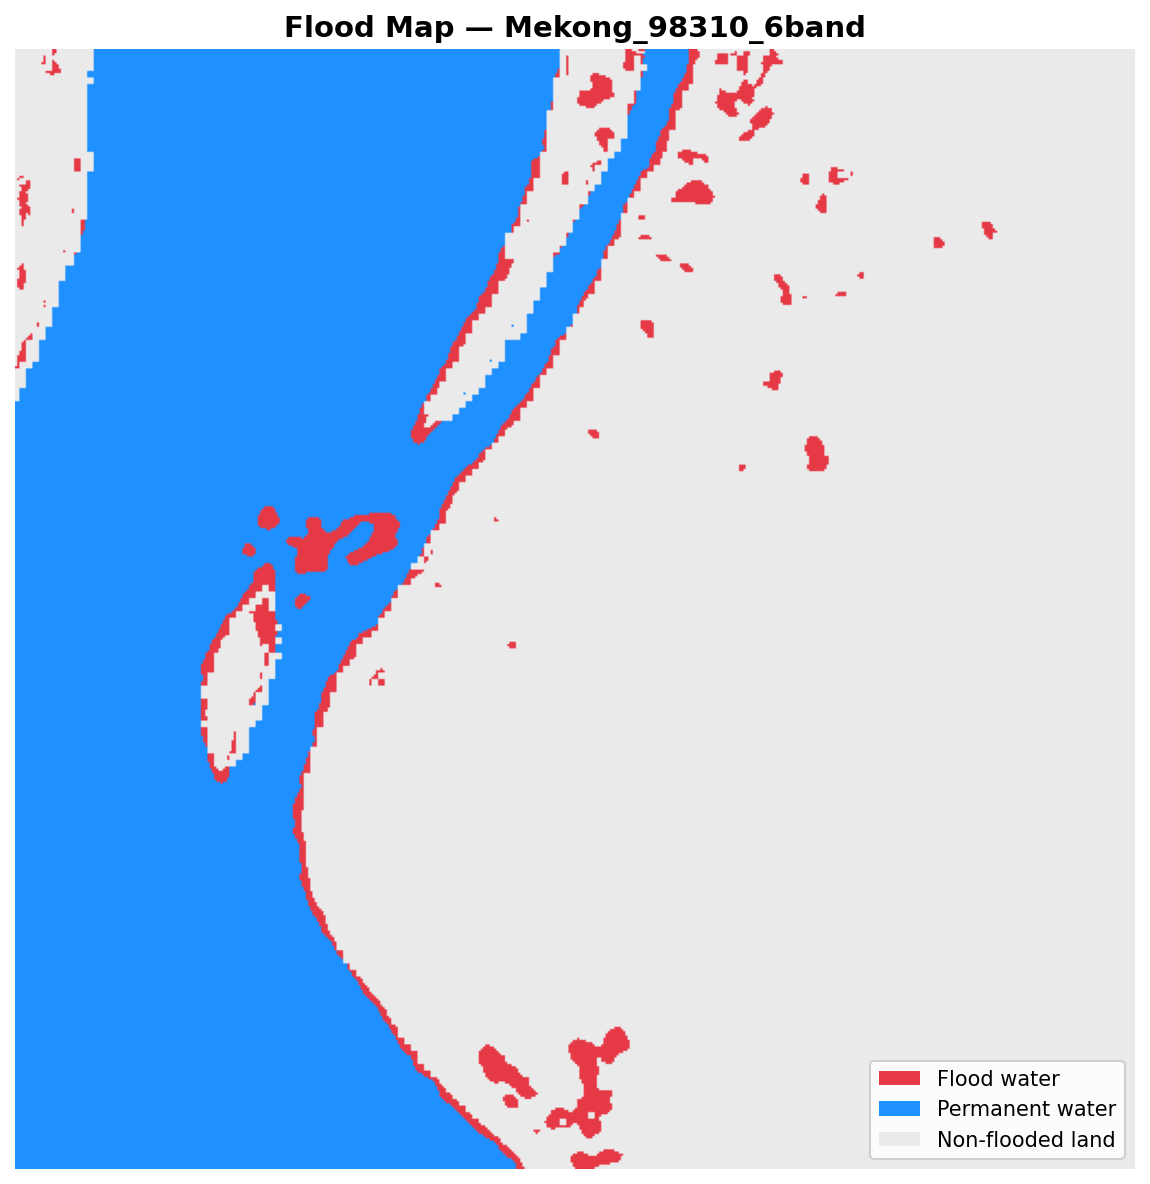

In [12]:
import numpy as np, rasterio
from IPython.display import Image

# Pick any chip ID present in the dataset

CHIP_ID  = 'Mekong_98310'   # or any from your top-10 list
DEMO_TIF = f'/kaggle/working/{CHIP_ID}_6band.tif'



# Read the 6 bands in correct order: VV, VH (from S1Hand), DEM, Slope, JRC, HAND
sources = [
    ('S1Hand',       1),  # VV  → channel 1
    ('S1Hand',       2),  # VH  → channel 2
    ('DEM',          1),  # DEM → channel 3
    ('Slope',        1),
    ('JRCWaterHand', 1),
    ('HAND',         1),
]
bands, profile = [], None
for subdir, b in sources:
    suffix = subdir
    p = f'{DATA_ROOT}/HandLabeled/{subdir}/{CHIP_ID}_{suffix}.tif'
    with rasterio.open(p) as src:
        if profile is None:
            profile = src.profile.copy()
        bands.append(src.read(b).astype(np.float32))

profile.update({'count': 6, 'dtype': 'float32'})
with rasterio.open(DEMO_TIF, 'w', **profile) as dst:
    for i, arr in enumerate(bands, 1):
        dst.write(arr, i)
print(f'Built 6-band stack at {DEMO_TIF}')

# Run inference
results = predictor.predict_from_geotiff(DEMO_TIF, OUT_DIR)
print(results['stats'])

# Show the red/blue map
Image(results['png'])


## 7. Visual - Using GEE

In [14]:
!pip install geedim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00


GEE initialized.


/usr/local/lib/python3.12/dist-packages/geedim/mask.py:579: FutureWarning: 'MaskedImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  super().__init__(ee_image)


  0%|          |0/245 tiles [00:00<?]

/usr/local/lib/python3.12/dist-packages/geedim/image.py:254: RuntimeWarning: Couldn't find STAC entry for: 'None'.
  return STACClient().get(self.id)


[GEE] Downloaded 6-band image → /kaggle/working/inference_outputs/gee_2018-02-15_-66.00_-13.70.tif
Read 7 bands; using first 6.
Flood pixels    :  1,260,129  (8.47%)
Permanent pixels:    178,942  (1.20%)
[GeoTIFF] Saved → /kaggle/working/inference_outputs/gee_2018-02-15_bolivia_class_map.tif
[GeoTIFF] Saved → /kaggle/working/inference_outputs/gee_2018-02-15_bolivia_flood_mask.tif
[GeoTIFF] Saved → /kaggle/working/inference_outputs/gee_2018-02-15_bolivia_permanent_water.tif
[Visualization] Saved → /kaggle/working/inference_outputs/gee_2018-02-15_bolivia_flood_map.png


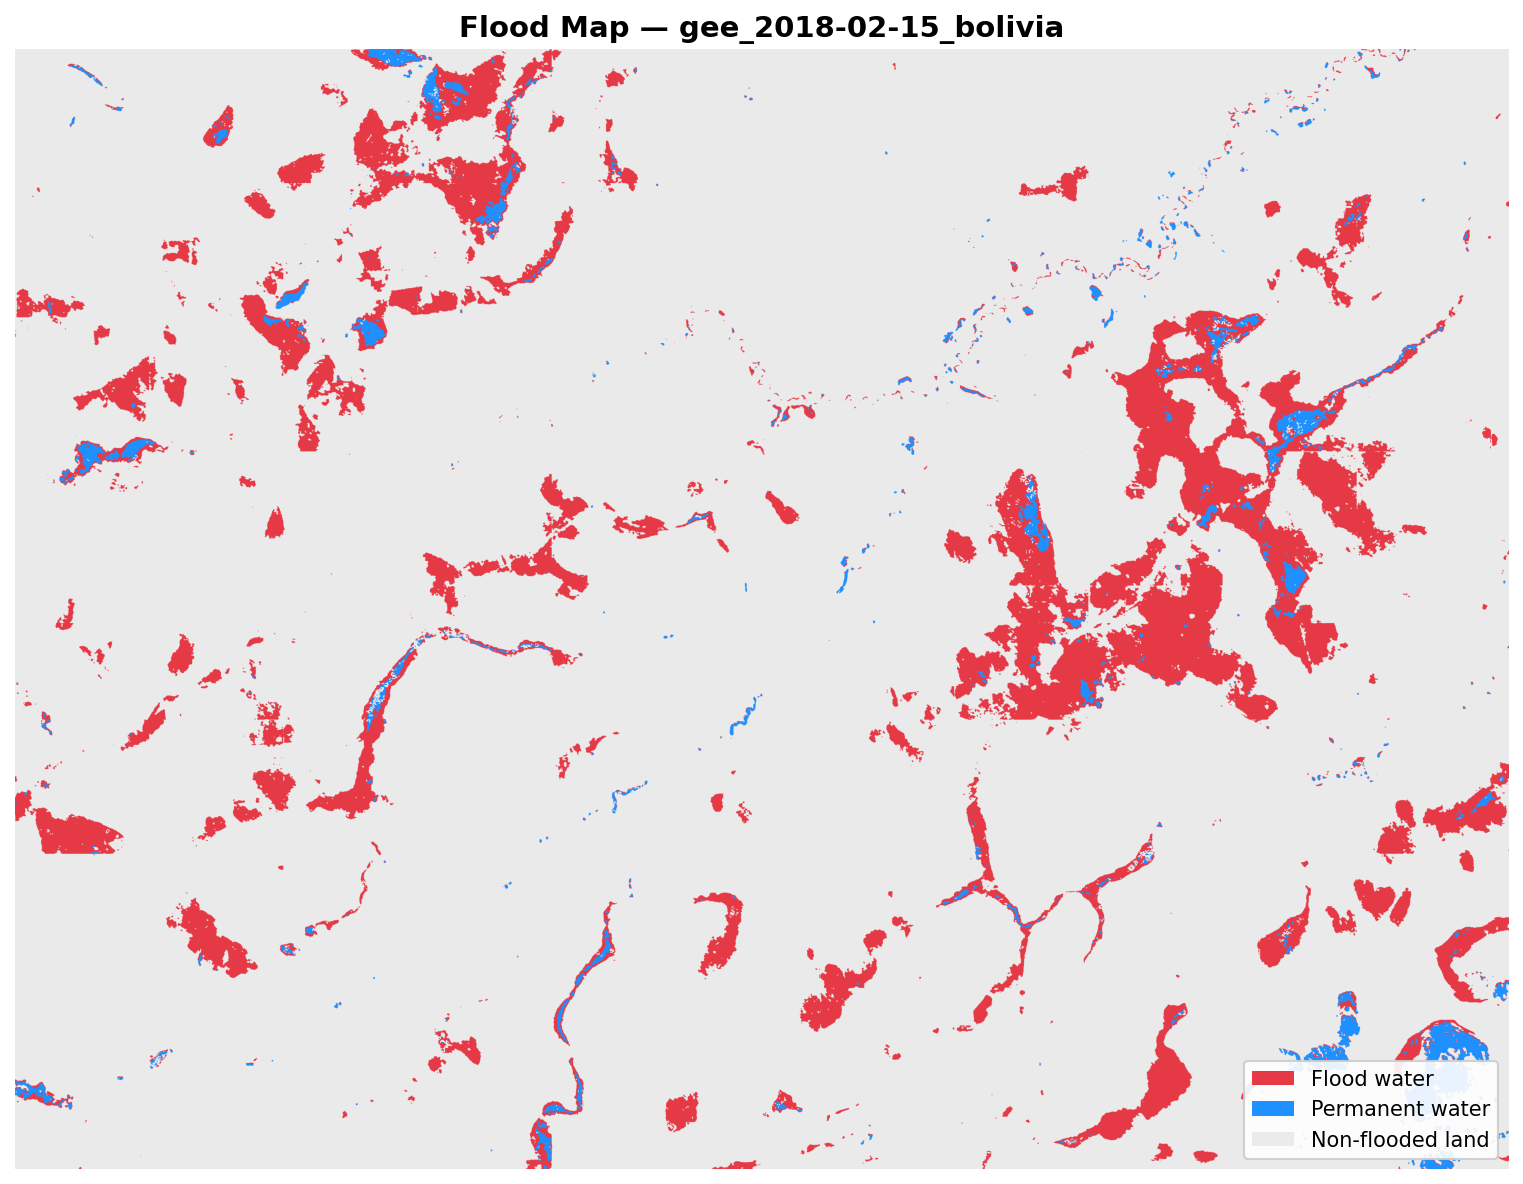

In [15]:
import os, torch, rasterio, numpy as np, ee
from inference import sliding_window_predict, postprocess, visualize_flood_map, save_geotiff
from dataset import normalize_band
from IPython.display import Image

OUT_DIR = '/kaggle/working/inference_outputs'
os.makedirs(OUT_DIR, exist_ok=True)
device  = predictor.device

# --- 0. GEE auth (skip this block if already done in this session) ---
SERVICE_ACCOUNT_FILE = '/kaggle/input/datasets/yash10chawla/last-try-key/gee-kaggle-project-fbe0b036073d.json'
credentials = ee.ServiceAccountCredentials(None, SERVICE_ACCOUNT_FILE)
ee.Initialize(credentials)
predictor.fetcher._ee_initialized = True
print('GEE initialized.')

# --- 1. Download a fresh 6-band GEE stack for the bbox + date ---
LON_MIN, LAT_MIN = -66.0, -13.7
LON_MAX, LAT_MAX = -65.6, -13.4
DATE             = '2018-02-15'

CACHED_TIF = f'{OUT_DIR}/gee_{DATE}_{LON_MIN:.2f}_{LAT_MIN:.2f}.tif'
predictor.fetcher.fetch(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX, DATE, CACHED_TIF)

# --- 2. Read the tif, keep only the first 6 bands ---
band_names = ['s1_vv', 's1_vh', 'dem', 'slope', 'jrc', 'hand']
with rasterio.open(CACHED_TIF) as src:
    profile = src.profile.copy()
    bands   = src.read().astype(np.float32)
print(f'Read {bands.shape[0]} bands; using first 6.')

normalized = np.stack(
    [normalize_band(bands[i], band_names[i]) for i in range(6)], axis=-1
)
raw_slope = bands[3]
raw_jrc   = bands[4]

# --- 3. Sliding-window inference ---
prob_map = sliding_window_predict(
    predictor.model, normalized, device,
    window=predictor.window_size, stride=predictor.stride,
)

# --- 4. Postprocess ---
class_map, flood_mask, perm_mask = postprocess(prob_map, raw_slope, raw_jrc)
print(f'Flood pixels    : {int(flood_mask.sum()):>10,d}  ({100*flood_mask.mean():.2f}%)')
print(f'Permanent pixels: {int(perm_mask.sum()):>10,d}  ({100*perm_mask.mean():.2f}%)')

# --- 5. Save outputs ---
base = f'gee_{DATE}_bolivia'
profile_out = profile.copy()
profile_out.update({'driver': 'GTiff', 'count': 1, 'dtype': 'uint8'})
profile_out.pop('nodata', None)

save_geotiff(class_map.astype(np.uint8),  profile_out, f'{OUT_DIR}/{base}_class_map.tif')
save_geotiff(flood_mask.astype(np.uint8), profile_out, f'{OUT_DIR}/{base}_flood_mask.tif')
save_geotiff(perm_mask.astype(np.uint8),  profile_out, f'{OUT_DIR}/{base}_permanent_water.tif')

png_path = f'{OUT_DIR}/{base}_flood_map.png'
visualize_flood_map(flood_mask, perm_mask, png_path,
                    title=f'Flood Map — {base}')

Image(png_path)


---
## Additional - Checking is the Output is Real

In [16]:
import ee, geedim, rasterio, numpy as np, matplotlib.pyplot as plt

LON_MIN, LAT_MIN = -66.0, -13.7
LON_MAX, LAT_MAX = -65.6, -13.4

# Pull JRC "max_extent" — pixels ever observed as water historically
region = ee.Geometry.Rectangle([LON_MIN, LAT_MIN, LON_MAX, LAT_MAX])
jrc_truth = (ee.Image('JRC/GSW1_4/GlobalSurfaceWater')
             .select('seasonality').unmask(0).clip(region))
geedim.MaskedImage(jrc_truth).download(
    f'{OUT_DIR}/jrc_truth.tif', region=region.getInfo(),
    scale=30, crs='EPSG:4326', overwrite=True)

with rasterio.open(f'{OUT_DIR}/jrc_truth.tif') as src:
    jrc = src.read(1)

# Resize JRC to match the model output
from rasterio.warp import reproject, Resampling
jrc_resized = np.zeros_like(perm_mask, dtype=np.float32)
with rasterio.open(f'{OUT_DIR}/jrc_truth.tif') as src:
    reproject(source=src.read(1).astype(np.float32), destination=jrc_resized,
              src_transform=src.transform, src_crs=src.crs,
              dst_transform=profile['transform'], dst_crs=profile['crs'],
              resampling=Resampling.nearest)

jrc_permanent_truth = (jrc_resized >= 5).astype(np.uint8)   # JRC seasonality >= 5 months

# Quantitative agreement
tp = ((perm_mask == 1) & (jrc_permanent_truth == 1)).sum()
fp = ((perm_mask == 1) & (jrc_permanent_truth == 0)).sum()
fn = ((perm_mask == 0) & (jrc_permanent_truth == 1)).sum()
iou = tp / max(tp + fp + fn, 1)
print(f'Model "permanent" vs JRC ground truth:')
print(f'  IoU      : {iou:.3f}')
print(f'  Precision: {tp / max(tp+fp, 1):.3f}  (fraction of model-blue that is real)')
print(f'  Recall   : {tp / max(tp+fn, 1):.3f}  (fraction of real permanent water the model catches)')




JRC/GSW1_4/GlobalSurfaceWater:   0%|          |0/4 tiles [00:00<?]

Model "permanent" vs JRC ground truth:
  IoU      : 0.027
  Precision: 0.027  (fraction of model-blue that is real)
  Recall   : 0.911  (fraction of real permanent water the model catches)


In [17]:
for thresh in (1, 2, 3, 5, 8):
    truth = (jrc_resized >= thresh).astype(np.uint8)
    tp = ((perm_mask == 1) & (truth == 1)).sum()
    fp = ((perm_mask == 1) & (truth == 0)).sum()
    fn = ((perm_mask == 0) & (truth == 1)).sum()
    iou       = tp / max(tp+fp+fn, 1)
    precision = tp / max(tp+fp, 1)
    recall    = tp / max(tp+fn, 1)
    print(f'JRC truth >= {thresh}: IoU={iou:.3f}  P={precision:.3f}  R={recall:.3f}  '
          f'(truth pixels={int(truth.sum()):,}  model pixels={int(perm_mask.sum()):,})')


JRC truth >= 1: IoU=0.720  P=0.849  R=0.825  (truth pixels=184,125  model pixels=178,942)
JRC truth >= 2: IoU=0.554  P=0.575  R=0.939  (truth pixels=109,662  model pixels=178,942)
JRC truth >= 3: IoU=0.210  P=0.212  R=0.962  (truth pixels=39,420  model pixels=178,942)
JRC truth >= 5: IoU=0.027  P=0.027  R=0.911  (truth pixels=5,349  model pixels=178,942)
JRC truth >= 8: IoU=0.007  P=0.007  R=0.843  (truth pixels=1,458  model pixels=178,942)


S2 images found: 2


/usr/local/lib/python3.12/dist-packages/geedim/mask.py:579: FutureWarning: 'MaskedImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  super().__init__(ee_image)


  0%|          |0/48 tiles [00:00<?]

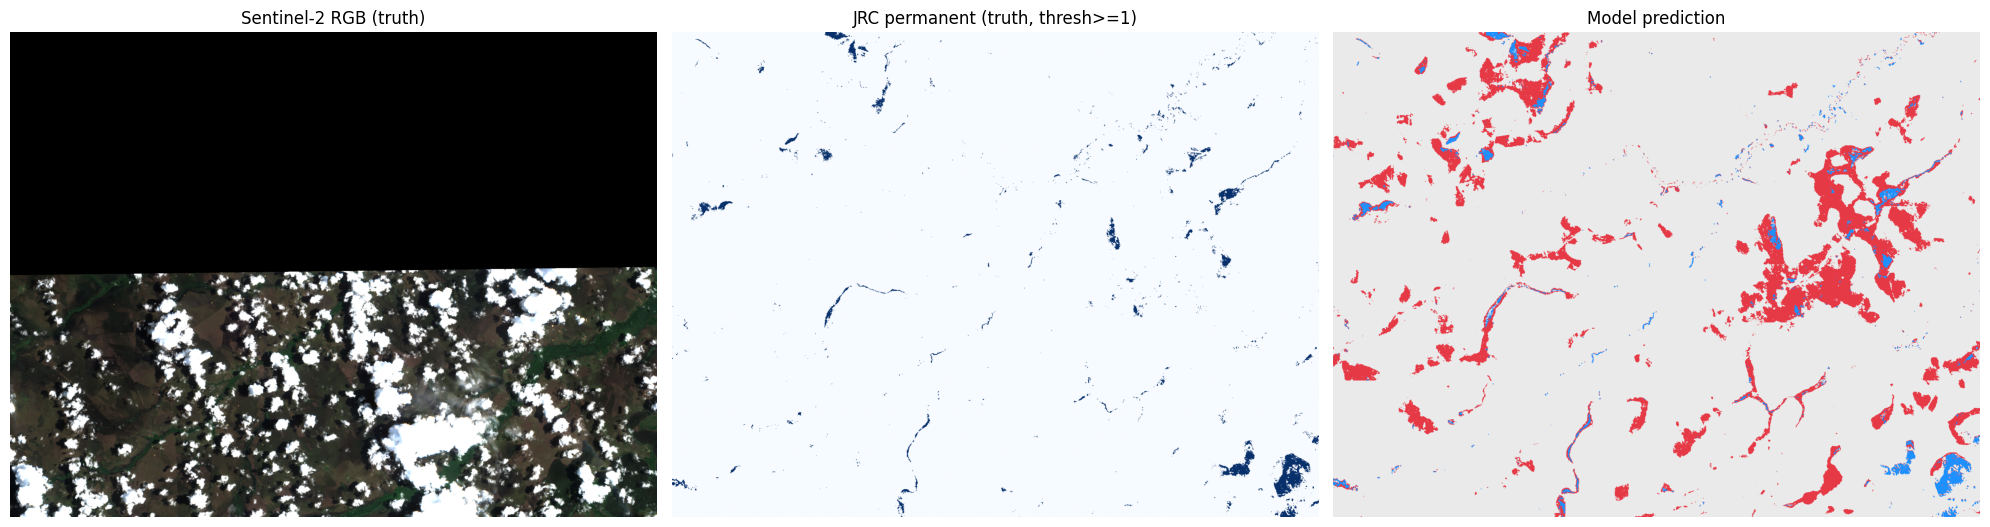

In [18]:
import ee, geedim, rasterio, numpy as np, matplotlib.pyplot as plt

region = ee.Geometry.Rectangle([LON_MIN, LAT_MIN, LON_MAX, LAT_MAX])

s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(region)
                 .filterDate('2018-01-15', '2018-03-15')           # ±1 month
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)))

n_imgs = s2_collection.size().getInfo()
print(f'S2 images found: {n_imgs}')
assert n_imgs > 0, 'No S2 images — widen dates or use S2 TOA / Landsat instead'

s2 = (s2_collection
      .median()
      .select(['B4', 'B3', 'B2'])
      .clip(region))

geedim.MaskedImage(s2).download(
    f'{OUT_DIR}/s2_rgb.tif', region=region.getInfo(),
    scale=20, crs='EPSG:4326', overwrite=True)

with rasterio.open(f'{OUT_DIR}/s2_rgb.tif') as src:
    rgb_raw = src.read([1,2,3]).astype(np.float32)
rgb = np.clip(rgb_raw / 3000, 0, 1).transpose(1, 2, 0)

# Side-by-side panel
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(rgb);                              axes[0].set_title('Sentinel-2 RGB (truth)'); axes[0].axis('off')
axes[1].imshow((jrc_resized >= 1), cmap='Blues'); axes[1].set_title('JRC permanent (truth, thresh>=1)'); axes[1].axis('off')

model_overlay = np.ones((*perm_mask.shape, 3), dtype=np.float32) * 0.92
model_overlay[perm_mask  == 1] = [0.118, 0.565, 1.0]
model_overlay[flood_mask == 1] = [0.902, 0.224, 0.275]
axes[2].imshow(model_overlay);                    axes[2].set_title('Model prediction'); axes[2].axis('off')
plt.tight_layout(); plt.show()


In [19]:
vv_db = bands[0]    # raw VV from your downloaded GEE tif (dB scale)
predicted_water = (flood_mask | perm_mask).astype(bool)

# What fraction of model-water pixels actually look like water in SAR?
water_vv = vv_db[predicted_water]
print(f'Model-water VV stats: mean={water_vv.mean():.1f} dB  '
      f'median={np.median(water_vv):.1f} dB  '
      f'(should be < -15 dB for true water)')

land_vv  = vv_db[~predicted_water]
print(f'Model-land  VV stats: mean={land_vv.mean():.1f} dB  '
      f'median={np.median(land_vv):.1f} dB  '
      f'(should be > -10 dB for true land)')


Model-water VV stats: mean=-11.2 dB  median=-10.3 dB  (should be < -15 dB for true water)
Model-land  VV stats: mean=-inf dB  median=-9.8 dB  (should be > -10 dB for true land)


In [20]:
import numpy as np

vv_db = bands[0]
predicted_water = (flood_mask | perm_mask).astype(bool)

# Mask out invalid pixels (no SAR data)
valid = np.isfinite(vv_db)

water_vv = vv_db[predicted_water & valid]
land_vv  = vv_db[~predicted_water & valid]

print(f'Valid pixel coverage: {100*valid.mean():.1f}% of bbox')
print(f'\nModel-water  ({water_vv.size:>9,} pixels):  '
      f'mean={water_vv.mean():.1f} dB  '
      f'median={np.median(water_vv):.1f} dB  '
      f'p10={np.percentile(water_vv, 10):.1f} dB  '
      f'p90={np.percentile(water_vv, 90):.1f} dB')
print(f'Model-land   ({land_vv.size:>9,} pixels):  '
      f'mean={land_vv.mean():.1f} dB  '
      f'median={np.median(land_vv):.1f} dB  '
      f'p10={np.percentile(land_vv, 10):.1f} dB  '
      f'p90={np.percentile(land_vv, 90):.1f} dB')

# Distinct-distribution sanity: water should have a clear left tail
print(f'\nFraction of model-water with VV < -15 dB: {(water_vv < -15).mean()*100:.1f}%  (open water signature)')
print(f'Fraction of model-water with VV < -10 dB: {(water_vv < -10).mean()*100:.1f}%  (water-or-flooded-veg)')


Valid pixel coverage: 100.0% of bbox

Model-water  (1,439,071 pixels):  mean=-11.2 dB  median=-10.3 dB  p10=-17.3 dB  p90=-6.6 dB
Model-land   (13,437,004 pixels):  mean=-9.8 dB  median=-9.8 dB  p10=-12.2 dB  p90=-7.2 dB

Fraction of model-water with VV < -15 dB: 16.9%  (open water signature)
Fraction of model-water with VV < -10 dB: 54.2%  (water-or-flooded-veg)


In [21]:
import os, torch, rasterio, numpy as np
from inference import sliding_window_predict, postprocess
from dataset import normalize_band

CHIP_ID    = 'Spain_5923267'
DATA_ROOT  = '/kaggle/input/datasets/yash10chawla/final-sendata'
device     = predictor.device

# --- 1. Build 6-band stack in memory (no need to write to disk) ---
sources = [('S1Hand', 1), ('S1Hand', 2), ('DEM', 1),
           ('Slope', 1), ('JRCWaterHand', 1), ('HAND', 1)]
band_names = ['s1_vv', 's1_vh', 'dem', 'slope', 'jrc', 'hand']
bands_raw = []
for subdir, b in sources:
    p = f'{DATA_ROOT}/HandLabeled/{subdir}/{CHIP_ID}_{subdir}.tif'
    with rasterio.open(p) as src:
        bands_raw.append(src.read(b).astype(np.float32))

normalized = np.stack(
    [normalize_band(bands_raw[i], band_names[i]) for i in range(6)], axis=-1
)
raw_slope = bands_raw[3]
raw_jrc   = bands_raw[4]

# --- 2. Run sliding-window prediction ---
prob_map = sliding_window_predict(
    predictor.model, normalized, device,
    window=predictor.window_size, stride=predictor.stride,
)
class_map, flood_mask, perm_mask = postprocess(prob_map, raw_slope, raw_jrc)
pred = class_map

# --- 3. Build the 3-class ground-truth label (same logic as training) ---
with rasterio.open(f'{DATA_ROOT}/HandLabeled/LabelHand/{CHIP_ID}_LabelHand.tif') as src:
    label_hand = src.read(1)
with rasterio.open(f'{DATA_ROOT}/HandLabeled/JRCWaterHand/{CHIP_ID}_JRCWaterHand.tif') as src:
    jrc_truth = src.read(1)

truth = label_hand.astype(np.int64).copy()
truth[(truth == 1) & (jrc_truth >= 0.5)] = 2

# --- 4. Per-class metrics on valid pixels ---
valid = truth >= 0
print(f'Valid pixels: {int(valid.sum()):,} / {truth.size:,} ({100*valid.mean():.1f}%)\n')
for c, name in [(1, 'flood'), (2, 'permanent')]:
    p = pred[valid] == c
    t = truth[valid] == c
    tp = (p & t).sum()
    fp = (p & ~t).sum()
    fn = (~p & t).sum()
    iou = tp / max(tp+fp+fn, 1)
    prec = tp / max(tp+fp, 1)
    rec  = tp / max(tp+fn, 1)
    print(f'{name:9s}: IoU={iou:.3f}  P={prec:.3f}  R={rec:.3f}  '
          f'(truth={int(t.sum()):,}  pred={int(p.sum()):,})')


Valid pixels: 218,743 / 262,144 (83.4%)

flood    : IoU=0.407  P=0.487  R=0.711  (truth=6,463  pred=9,429)
permanent: IoU=0.985  P=0.995  R=0.990  (truth=195,250  pred=194,168)
